In [4]:
%pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report

from xgboost import XGBClassifier
import shap
import joblib

In [6]:
file_path = r"D:\Hex credit\data\archive (3)\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
selected_columns = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'dti',
    'delinq_2yrs',
    'open_acc',
    'revol_bal',
    'revol_util',
    'total_acc',
    'application_type',
    'loan_status'
]

df = df[selected_columns]

In [8]:
valid_status = ['Fully Paid', 'Charged Off', 'Default']

df = df[df['loan_status'].isin(valid_status)]

In [9]:
df['loan_status'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off','Default'] else 0
)

In [10]:
df = df.dropna()

In [11]:
label_encoders = {}

for column in df.select_dtypes(include=['object']).columns:
    
    le = LabelEncoder()
    
    df[column] = le.fit_transform(df[column])
    
    label_encoders[column] = le

In [12]:
df["loan_income_ratio"] = df["loan_amnt"] / (df["annual_inc"] + 1)

df["credit_utilization"] = df["revol_bal"] / (df["annual_inc"] + 1)

df["accounts_per_income"] = df["open_acc"] / (df["annual_inc"] + 1)

df["loan_installment_ratio"] = df["installment"] / (df["annual_inc"] + 1)

df["debt_burden"] = df["dti"] * df["loan_amnt"]

In [13]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
positive = sum(y_train == 1)
negative = sum(y_train == 0)

scale_pos_weight = negative / positive

print(scale_pos_weight)

4.128037913156189


In [16]:
param_grid = {
    "n_estimators":[200,400],
    "max_depth":[5,7],
    "learning_rate":[0.05,0.1],
    "subsample":[0.8,1],
    "colsample_bytree":[0.8,1]
}

In [17]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    use_label_encoder=False
)

In [18]:
grid = GridSearchCV(
    xgb,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


c:\Users\legion\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:23:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.05, 0.1], 'max_depth': [5, 7],
                         'n_estimators': [200, 400], 'subsample': [0.8, 1]},
             scoring='roc_auc', verbose=2)

In [19]:
print(grid.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 400, 'subsample': 1}


In [20]:
import joblib

best_model = grid.best_estimator_

joblib.dump(best_model, "credit_model.pkl")

print("Model saved successfully")

Model saved successfully


In [21]:
import joblib

best_model = joblib.load("credit_model.pkl")

In [22]:
sample = X_test.iloc[[0]]

In [23]:
prediction = best_model.predict(sample)

probability = best_model.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [1]
Probability: [[0.42508328 0.5749167 ]]


In [24]:
joblib.dump(best_model, "credit_model.pkl")

['credit_model.pkl']

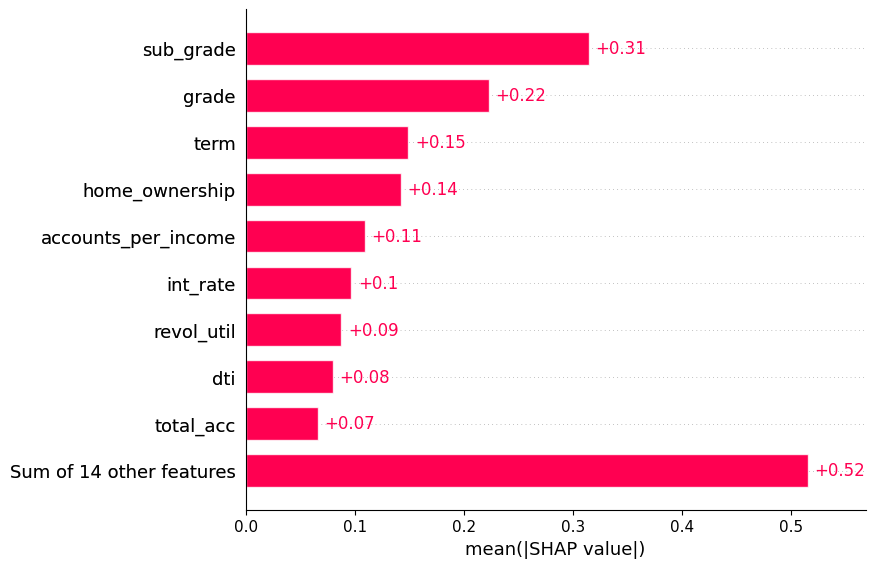

In [25]:
explainer = shap.Explainer(best_model)

shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

In [26]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgb_model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5
)

lgb_model.fit(X_train, y_train)

pred_prob = lgb_model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, pred_prob)

print("LightGBM ROC-AUC:", roc)

[LightGBM] [Info] Number of positive: 197504, number of negative: 815304
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3322
[LightGBM] [Info] Number of data points in the train set: 1012808, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.195006 -> initscore=-1.417802
[LightGBM] [Info] Start training from score -1.417802
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

In [28]:
xgb_model = grid.best_estimator_

In [29]:
from sklearn.metrics import roc_auc_score

# XGBoost prediction
xgb_pred = xgb_model.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_pred)

# LightGBM prediction
lgb_pred = lgb_model.predict_proba(X_test)[:,1]
lgb_auc = roc_auc_score(y_test, lgb_pred)

In [30]:
print("Model Performance Comparison")
print("----------------------------")
print(f"XGBoost ROC-AUC : {xgb_auc:.4f}")
print(f"LightGBM ROC-AUC: {lgb_auc:.4f}")

Model Performance Comparison
----------------------------
XGBoost ROC-AUC : 0.7214
LightGBM ROC-AUC: 0.7195


In [31]:
best_model = xgb_model if xgb_auc > lgb_auc else lgb_model

print("\nBest Model Selected:", type(best_model).__name__)


Best Model Selected: XGBClassifier


In [32]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict_proba(X_test)[:,1]

cat_auc = roc_auc_score(y_test, cat_pred)

print("CatBoost ROC-AUC:", round(cat_auc,4))

CatBoost ROC-AUC: 0.7192


In [34]:
import pandas as pd

results = pd.DataFrame({
    "Model":["XGBoost","LightGBM","CatBoost"],
    "ROC-AUC":[xgb_auc,lgb_auc,cat_auc]
})

print(results)

      Model   ROC-AUC
0   XGBoost  0.721442
1  LightGBM  0.719507
2  CatBoost  0.719227


In [35]:
ensemble_pred = (
    0.5 * xgb_model.predict_proba(X_test)[:,1] +
    0.3 * cat_model.predict_proba(X_test)[:,1] +
    0.2 * lgb_model.predict_proba(X_test)[:,1]
)

In [36]:
from sklearn.metrics import roc_auc_score

ensemble_auc = roc_auc_score(y_test, ensemble_pred)

print("Ensemble ROC-AUC:", round(ensemble_auc,4))

Ensemble ROC-AUC: 0.7212


In [37]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "CatBoost", "Ensemble"],
    "ROC-AUC": [xgb_auc, lgb_auc, cat_auc, ensemble_auc]
})

print(results)

      Model   ROC-AUC
0   XGBoost  0.721442
1  LightGBM  0.719507
2  CatBoost  0.719227
3  Ensemble  0.721246


In [38]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, y, cv=5, scoring="roc_auc")

print("Mean ROC-AUC:", scores.mean())

c:\Users\legion\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:24:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\legion\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:24:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\legion\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:25:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\legion\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:25:22] WARNING: C:\a

Mean ROC-AUC: 0.7083317573588341


In [39]:
df["loan_income_ratio"] = df["loan_amnt"] / (df["annual_inc"] + 1)

df["installment_income_ratio"] = df["installment"] / (df["annual_inc"] + 1)

df["credit_utilization"] = df["revol_bal"] / (df["annual_inc"] + 1)

df["account_pressure"] = df["open_acc"] / (df["total_acc"] + 1)

df["debt_stress"] = df["dti"] * df["loan_amnt"]

In [40]:
df = df[df["annual_inc"] < df["annual_inc"].quantile(0.99)]
df = df[df["dti"] < df["dti"].quantile(0.99)]
df = df[df["loan_amnt"] < df["loan_amnt"].quantile(0.99)]

In [41]:
y.value_counts()

loan_status
0    1018716
1     247295
Name: count, dtype: int64

In [42]:
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)

In [43]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [46]:
from sklearn.metrics import roc_auc_score

# Predict probabilities
pred_prob = xgb_model.predict_proba(X_test)[:,1]

# Calculate ROC-AUC
roc = roc_auc_score(y_test, pred_prob)

print("New ROC-AUC:", round(roc,4))

New ROC-AUC: 0.7217


In [47]:
print("Previous ROC-AUC:", round(xgb_auc,4))
print("New ROC-AUC:", round(roc,4))

Previous ROC-AUC: 0.7214
New ROC-AUC: 0.7217


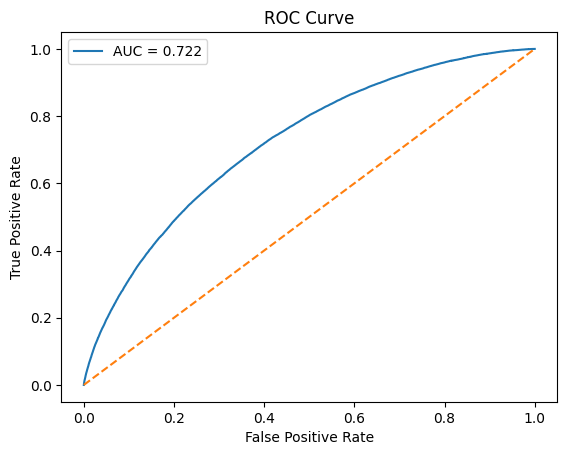

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, pred_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [49]:
print("Fold Scores:", scores)
print("Mean ROC-AUC:", scores.mean())

Fold Scores: [0.73804248 0.71393646 0.70491098 0.70093793 0.68383094]
Mean ROC-AUC: 0.7083317573588341


In [50]:
from sklearn.metrics import roc_auc_score

# Training predictions
train_pred = xgb_model.predict_proba(X_train)[:,1]

train_auc = roc_auc_score(y_train, train_pred)

print("Training ROC-AUC:", round(train_auc,4))

Training ROC-AUC: 0.739


In [51]:
test_pred = xgb_model.predict_proba(X_test)[:,1]

test_auc = roc_auc_score(y_test, test_pred)

print("Test ROC-AUC:", round(test_auc,4))

Test ROC-AUC: 0.7217


In [52]:
print("Train ROC-AUC:", round(train_auc,4))
print("Test ROC-AUC :", round(test_auc,4))
print("Gap:", round(train_auc - test_auc,4))

Train ROC-AUC: 0.739
Test ROC-AUC : 0.7217
Gap: 0.0172


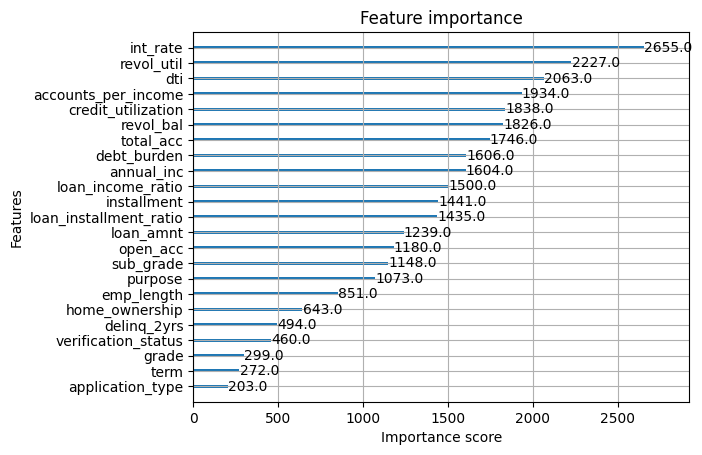

In [53]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(xgb_model)
plt.show()

In [54]:
import numpy as np

# Loan burden
df["loan_to_income_ratio"] = df["loan_amnt"] / (df["annual_inc"] + 1)

# Monthly income
df["monthly_income"] = df["annual_inc"] / 12

# EMI burden
df["emi_to_income_ratio"] = df["installment"] / (df["monthly_income"] + 1)

# Credit utilization ratio
df["credit_utilization_ratio"] = df["revol_bal"] / (df["loan_amnt"] + 1)

# Credit exposure per account
df["avg_credit_per_account"] = df["revol_bal"] / (df["open_acc"] + 1)

# Delinquency risk score
df["delinq_ratio"] = df["delinq_2yrs"] / (df["total_acc"] + 1)

# Log income (helps ML models)
df["log_income"] = np.log1p(df["annual_inc"])

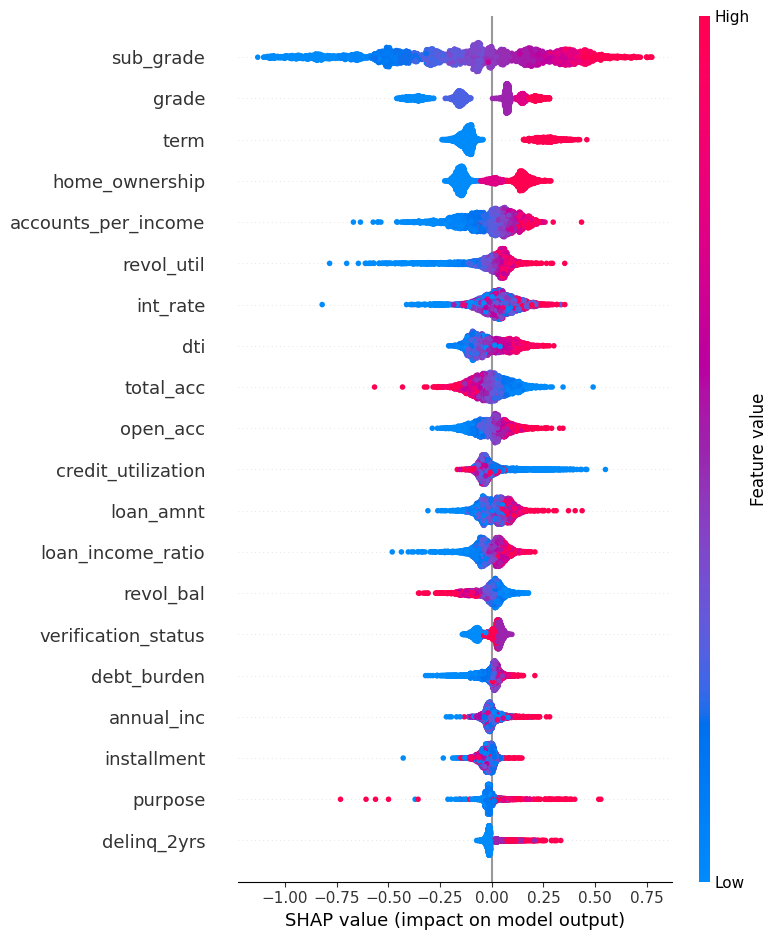

In [55]:
import shap

sample_X = X_test.sample(3000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(sample_X)

shap.summary_plot(shap_values, sample_X)

In [58]:
import joblib

# Save training columns
training_columns = X.columns.tolist()

joblib.dump(training_columns, "training_columns.pkl")

# Save model
joblib.dump(best_model, "credit_model.pkl")


['credit_model.pkl']